In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, log_loss
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from xgboost import XGBClassifier
import distance
import re
import os
from bs4 import BeautifulSoup

import warnings
warnings.filterwarnings('ignore')
from fuzzywuzzy import fuzz


In [80]:
full_df = pd.read_csv(r"C:\Users\megha\Downloads\Projects\Duplicate Pairs Recognition\train.csv")
full_df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [81]:
df = full_df.sample(30000)
df.reset_index(inplace = True)
df.drop(columns = ['index','id','qid1','qid2'],axis = 1,inplace = True)


In [82]:
def preprocess(q):
    
    q = str(q).lower().strip()
    
    # Replace certain special characters with their string equivalents
    q = q.replace('%', ' percent')
    q = q.replace('$', ' dollar ')
    q = q.replace('₹', ' rupee ')
    q = q.replace('€', ' euro ')
    q = q.replace('@', ' at ')
    

    q = q.replace('[math]', '')
    
   
    q = q.replace(',000,000,000 ', 'b ')
    q = q.replace(',000,000 ', 'm ')
    q = q.replace(',000 ', 'k ')
    q = re.sub(r'([0-9]+)000000000', r'\1b', q)
    q = re.sub(r'([0-9]+)000000', r'\1m', q)
    q = re.sub(r'([0-9]+)000', r'\1k', q)
    
    contractions = { 
    "ain't": "am not",
    "aren't": "are not",
    "can't": "can not",
    "can't've": "can not have",
    "'cause": "because",
    "could've": "could have",
    "couldn't": "could not",
    "couldn't've": "could not have",
    "didn't": "did not",
    "doesn't": "does not",
    "don't": "do not",
    "hadn't": "had not",
    "hadn't've": "had not have",
    "hasn't": "has not",
    "haven't": "have not",
    "he'd": "he would",
    "he'd've": "he would have",
    "he'll": "he will",
    "he'll've": "he will have",
    "he's": "he is",
    "how'd": "how did",
    "how'd'y": "how do you",
    "how'll": "how will",
    "how's": "how is",
    "i'd": "i would",
    "i'd've": "i would have",
    "i'll": "i will",
    "i'll've": "i will have",
    "i'm": "i am",
    "i've": "i have",
    "isn't": "is not",
    "it'd": "it would",
    "it'd've": "it would have",
    "it'll": "it will",
    "it'll've": "it will have",
    "it's": "it is",
    "let's": "let us",
    "ma'am": "madam",
    "mayn't": "may not",
    "might've": "might have",
    "mightn't": "might not",
    "mightn't've": "might not have",
    "must've": "must have",
    "mustn't": "must not",
    "mustn't've": "must not have",
    "needn't": "need not",
    "needn't've": "need not have",
    "o'clock": "of the clock",
    "oughtn't": "ought not",
    "oughtn't've": "ought not have",
    "shan't": "shall not",
    "sha'n't": "shall not",
    "shan't've": "shall not have",
    "she'd": "she would",
    "she'd've": "she would have",
    "she'll": "she will",
    "she'll've": "she will have",
    "she's": "she is",
    "should've": "should have",
    "shouldn't": "should not",
    "shouldn't've": "should not have",
    "so've": "so have",
    "so's": "so as",
    "that'd": "that would",
    "that'd've": "that would have",
    "that's": "that is",
    "there'd": "there would",
    "there'd've": "there would have",
    "there's": "there is",
    "they'd": "they would",
    "they'd've": "they would have",
    "they'll": "they will",
    "they'll've": "they will have",
    "they're": "they are",
    "they've": "they have",
    "to've": "to have",
    "wasn't": "was not",
    "we'd": "we would",
    "we'd've": "we would have",
    "we'll": "we will",
    "we'll've": "we will have",
    "we're": "we are",
    "we've": "we have",
    "weren't": "were not",
    "what'll": "what will",
    "what'll've": "what will have",
    "what're": "what are",
    "what's": "what is",
    "what've": "what have",
    "when's": "when is",
    "when've": "when have",
    "where'd": "where did",
    "where's": "where is",
    "where've": "where have",
    "who'll": "who will",
    "who'll've": "who will have",
    "who's": "who is",
    "who've": "who have",
    "why's": "why is",
    "why've": "why have",
    "will've": "will have",
    "won't": "will not",
    "won't've": "will not have",
    "would've": "would have",
    "wouldn't": "would not",
    "wouldn't've": "would not have",
    "y'all": "you all",
    "y'all'd": "you all would",
    "y'all'd've": "you all would have",
    "y'all're": "you all are",
    "y'all've": "you all have",
    "you'd": "you would",
    "you'd've": "you would have",
    "you'll": "you will",
    "you'll've": "you will have",
    "you're": "you are",
    "you've": "you have"
    }

    q_decontracted = []

    for word in q.split():
        if word in contractions:
            word = contractions[word]

        q_decontracted.append(word)

    q = ' '.join(q_decontracted)
    q = q.replace("'ve", " have")
    q = q.replace("n't", " not")
    q = q.replace("'re", " are")
    q = q.replace("'ll", " will")
    

    q = BeautifulSoup(q)
    q = q.get_text()
    
    pattern = re.compile('\W')
    q = re.sub(pattern, ' ', q).strip()

    
    return q

In [83]:
df['question1'] = df['question1'].apply(lambda x: preprocess(x))
df['question2'] = df['question2'].apply(lambda x: preprocess(x))

In [84]:
df['q1_len'] = df['question1'].str.len() 
df['q2_len'] = df['question2'].str.len()

In [85]:
df['q1_num_words'] = df['question1'].apply(lambda row: len(row.split(" ")))
df['q2_num_words'] = df['question2'].apply(lambda row: len(row.split(" ")))
df.head()

,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words
0,the united nations organization has made the w...,how do i not fall asleep and distracted after ...,0,102,76,17,15
1,what is the difference between the army and th...,why and how do the marines fall under differin...,0,78,67,13,13
2,why india is not releasing video of surgical s...,why cant india expose pakistan s support to te...,1,63,93,11,15
3,why is rotatum is an unphysical quantity,what is the difference between rotatum power ...,0,40,61,7,11
4,what is the best way to learn discipline,how do i develop discipline,1,40,27,8,5


In [86]:
def common_words(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))    
    return len(w1 & w2)

In [87]:
df['word_common'] = df.apply(common_words, axis=1)
df.head()

,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common
0,the united nations organization has made the w...,how do i not fall asleep and distracted after ...,0,102,76,17,15,1
1,what is the difference between the army and th...,why and how do the marines fall under differin...,0,78,67,13,13,4
2,why india is not releasing video of surgical s...,why cant india expose pakistan s support to te...,1,63,93,11,15,7
3,why is rotatum is an unphysical quantity,what is the difference between rotatum power ...,0,40,61,7,11,2
4,what is the best way to learn discipline,how do i develop discipline,1,40,27,8,5,1


In [88]:
def total_words(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))    
    return (len(w1) + len(w2))

In [89]:
df['word_total'] = df.apply(total_words, axis=1)
df.head()

,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total
0,the united nations organization has made the w...,how do i not fall asleep and distracted after ...,0,102,76,17,15,1,30
1,what is the difference between the army and th...,why and how do the marines fall under differin...,0,78,67,13,13,4,23
2,why india is not releasing video of surgical s...,why cant india expose pakistan s support to te...,1,63,93,11,15,7,26
3,why is rotatum is an unphysical quantity,what is the difference between rotatum power ...,0,40,61,7,11,2,16
4,what is the best way to learn discipline,how do i develop discipline,1,40,27,8,5,1,13


In [90]:
df['word_share'] = round(df['word_common']/df['word_total'],2)
df.head()

,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share
0,the united nations organization has made the w...,how do i not fall asleep and distracted after ...,0,102,76,17,15,1,30,0.03
1,what is the difference between the army and th...,why and how do the marines fall under differin...,0,78,67,13,13,4,23,0.17
2,why india is not releasing video of surgical s...,why cant india expose pakistan s support to te...,1,63,93,11,15,7,26,0.27
3,why is rotatum is an unphysical quantity,what is the difference between rotatum power ...,0,40,61,7,11,2,16,0.12
4,what is the best way to learn discipline,how do i develop discipline,1,40,27,8,5,1,13,0.08




## Advance Features

### Tokens
- cwc_min: This is the ratio of the number of common words to the length of the smaller question
- cwc_max: This is the ratio of the number of common words to the length of the larger question
- csc_min: This is the ratio of the number of common stop words to the smaller stop word count among the two questions
- csc_max: This is the ratio of the number of common stop words to the larger stop word count among the two questions
- ctc_min: This is the ratio of the number of common tokens to the smaller token count among the two questions
- ctc_max: This is the ratio of the number of common tokens to the larger token count among the two questions
- last_word_eq: 1 if the last word in the two questions is same, 0 otherwise
- first_word_eq: 1 if the first word in the two questions is same, 0 otherwise

### Length Based Featres
- mean_len: Mean of the length of the two questions (number of words)
- abs_len_diff: Absolute difference between the length of the two questions (number of words)
- longest_substr_ratio: Ratio of the length of the longest substring among the two questions to the length of the smaller question

### Fuzzy Features
- fuzz_ratio: fuzz_ratio score from fuzzywuzzy
- fuzz_partial_ratio: fuzz_partial_ratio from fuzzywuzzy
- token_sort_ratio: token_sort_ratio from fuzzywuzzy
- token_set_ratio: token_set_ratio from fuzzywuzzy

In [91]:
# Advanced Features

def fetch_token_features(row):
    
    q1 = row['question1']
    q2 = row['question2']
    
    SAFE_DIV = 0.0001 

    STOP_WORDS = stopwords.words("english")
    
    token_features = [0.0]*8
    
    # Converting the Sentence into Tokens: 
    q1_tokens = q1.split()
    q2_tokens = q2.split()
    
    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return token_features

    # Get the non-stopwords in Questions
    q1_words = set([word for word in q1_tokens if word not in STOP_WORDS])
    q2_words = set([word for word in q2_tokens if word not in STOP_WORDS])
    
    #Get the stopwords in Questions
    q1_stops = set([word for word in q1_tokens if word in STOP_WORDS])
    q2_stops = set([word for word in q2_tokens if word in STOP_WORDS])
    
    # Get the common non-stopwords from Question pair
    common_word_count = len(q1_words.intersection(q2_words))
    
    # Get the common stopwords from Question pair
    common_stop_count = len(q1_stops.intersection(q2_stops))
    
    # Get the common Tokens from Question pair
    common_token_count = len(set(q1_tokens).intersection(set(q2_tokens)))
    
    
    token_features[0] = common_word_count / (min(len(q1_words), len(q2_words)) + SAFE_DIV)
    token_features[1] = common_word_count / (max(len(q1_words), len(q2_words)) + SAFE_DIV)
    token_features[2] = common_stop_count / (min(len(q1_stops), len(q2_stops)) + SAFE_DIV)
    token_features[3] = common_stop_count / (max(len(q1_stops), len(q2_stops)) + SAFE_DIV)
    token_features[4] = common_token_count / (min(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)
    token_features[5] = common_token_count / (max(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)
    
    # Last word of both question is same or not
    token_features[6] = int(q1_tokens[-1] == q2_tokens[-1])
    
    # First word of both question is same or not
    token_features[7] = int(q1_tokens[0] == q2_tokens[0])
    
    return token_features

In [92]:
token_features = df.apply(fetch_token_features, axis=1)

df["cwc_min"]       = list(map(lambda x: x[0], token_features))
df["cwc_max"]       = list(map(lambda x: x[1], token_features))
df["csc_min"]       = list(map(lambda x: x[2], token_features))
df["csc_max"]       = list(map(lambda x: x[3], token_features))
df["ctc_min"]       = list(map(lambda x: x[4], token_features))
df["ctc_max"]       = list(map(lambda x: x[5], token_features))
df["last_word_eq"]  = list(map(lambda x: x[6], token_features))
df["first_word_eq"] = list(map(lambda x: x[7], token_features))

In [93]:
def fetch_length_features(row):
    
    q1 = row['question1']
    q2 = row['question2']
    
    length_features = [0.0]*3
    
    # Converting the Sentence into Tokens: 
    q1_tokens = q1.split()
    q2_tokens = q2.split()
    
    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return length_features
    
    # Absolute length features
    length_features[0] = abs(len(q1_tokens) - len(q2_tokens))
    
    #Average Token Length of both Questions
    length_features[1] = (len(q1_tokens) + len(q2_tokens))/2
    
    strs = list(distance.lcsubstrings(q1, q2))
    length_features[2] = len(strs[0]) / (min(len(q1), len(q2)) + 1)
    
    return length_features

In [94]:
length_features = df.apply(fetch_length_features, axis=1)

df['abs_len_diff'] = list(map(lambda x: x[0], length_features))
df['mean_len'] = list(map(lambda x: x[1], length_features))
df['longest_substr_ratio'] = list(map(lambda x: x[2], length_features))

In [95]:
df.head()

,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share,...,cwc_max,csc_min,csc_max,ctc_min,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio
0,the united nations organization has made the w...,how do i not fall asleep and distracted after ...,0,102,76,17,15,1,30,0.03,...,0.000000,0.249994,0.111110,0.066666,0.066666,0.0,0.0,0.0,15.0,0.064935
1,what is the difference between the army and th...,why and how do the marines fall under differin...,0,78,67,13,13,4,23,0.17,...,0.399992,0.399992,0.285710,0.333331,0.307690,0.0,0.0,1.0,12.5,0.191176
2,why india is not releasing video of surgical s...,why cant india expose pakistan s support to te...,1,63,93,11,15,7,26,0.27,...,0.499995,0.399992,0.399992,0.636358,0.466664,0.0,1.0,4.0,13.0,0.546875
3,why is rotatum is an unphysical quantity,what is the difference between rotatum power ...,0,40,61,7,11,2,16,0.12,...,0.249994,0.333322,0.199996,0.285710,0.222220,0.0,0.0,2.0,8.0,0.219512
4,what is the best way to learn discipline,how do i develop discipline,1,40,27,8,5,1,13,0.08,...,0.249994,0.000000,0.000000,0.199996,0.124998,1.0,0.0,3.0,6.5,0.392857


In [96]:
# Fuzzy Features

def fetch_fuzzy_features(row):
    
    q1 = row['question1']
    q2 = row['question2']
    
    fuzzy_features = [0.0]*4
    
    # fuzz_ratio
    fuzzy_features[0] = fuzz.QRatio(q1, q2)

    # fuzz_partial_ratio
    fuzzy_features[1] = fuzz.partial_ratio(q1, q2)

    # token_sort_ratio
    fuzzy_features[2] = fuzz.token_sort_ratio(q1, q2)

    # token_set_ratio
    fuzzy_features[3] = fuzz.token_set_ratio(q1, q2)

    return fuzzy_features

In [97]:
fuzzy_features = df.apply(fetch_fuzzy_features, axis=1)

# Creating new feature columns for fuzzy features
df['fuzz_ratio'] = list(map(lambda x: x[0], fuzzy_features))
df['fuzz_partial_ratio'] = list(map(lambda x: x[1], fuzzy_features))
df['token_sort_ratio'] = list(map(lambda x: x[2], fuzzy_features))
df['token_set_ratio'] = list(map(lambda x: x[3], fuzzy_features))

In [98]:
df.head()

,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
0,the united nations organization has made the w...,how do i not fall asleep and distracted after ...,0,102,76,17,15,1,30,0.03,...,0.066666,0.0,0.0,0.0,15.0,0.064935,25,24,30,30
1,what is the difference between the army and th...,why and how do the marines fall under differin...,0,78,67,13,13,4,23,0.17,...,0.307690,0.0,0.0,1.0,12.5,0.191176,40,50,65,50
2,why india is not releasing video of surgical s...,why cant india expose pakistan s support to te...,1,63,93,11,15,7,26,0.27,...,0.466664,0.0,1.0,4.0,13.0,0.546875,65,70,68,84
3,why is rotatum is an unphysical quantity,what is the difference between rotatum power ...,0,40,61,7,11,2,16,0.12,...,0.222220,0.0,0.0,2.0,8.0,0.219512,38,39,38,43
4,what is the best way to learn discipline,how do i develop discipline,1,40,27,8,5,1,13,0.08,...,0.124998,1.0,0.0,3.0,6.5,0.392857,54,64,51,54


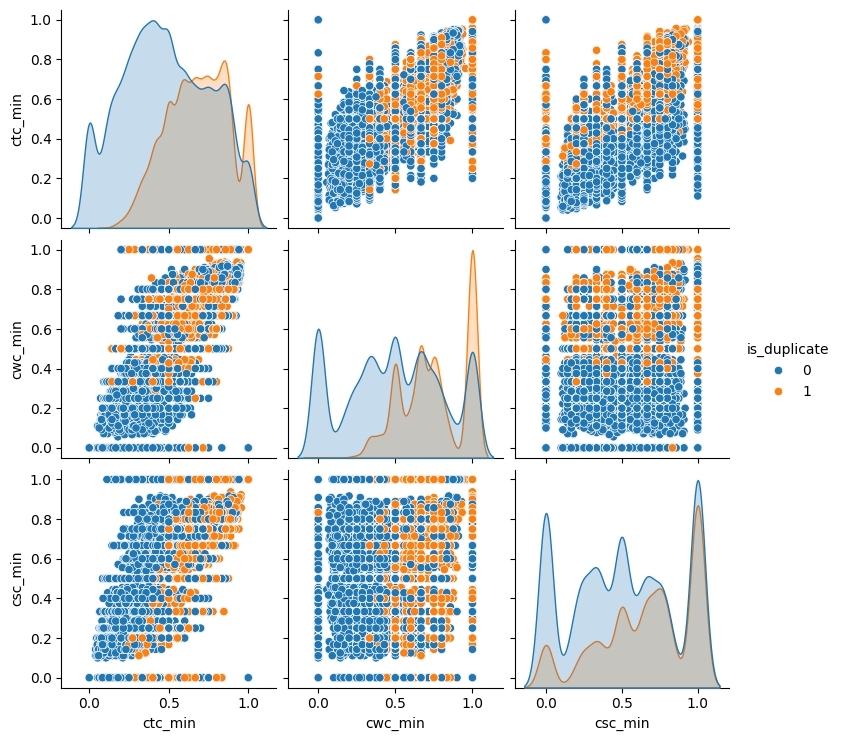

In [99]:
sns.pairplot(df[['ctc_min', 'cwc_min', 'csc_min', 'is_duplicate']],hue='is_duplicate')

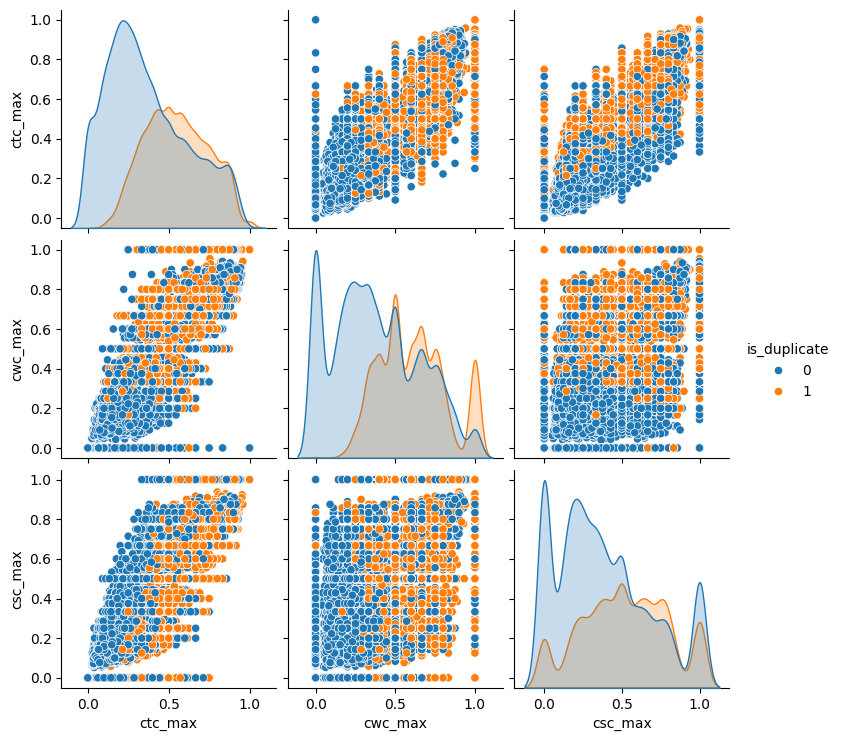

In [100]:
sns.pairplot(df[['ctc_max', 'cwc_max', 'csc_max', 'is_duplicate']],hue='is_duplicate')

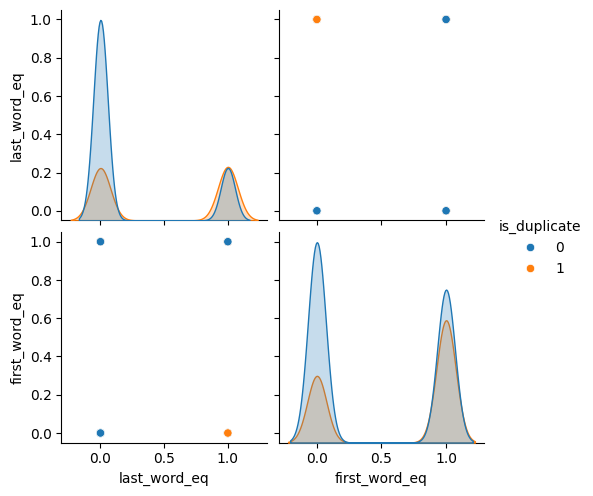

In [101]:
sns.pairplot(df[['last_word_eq', 'first_word_eq', 'is_duplicate']],hue='is_duplicate')

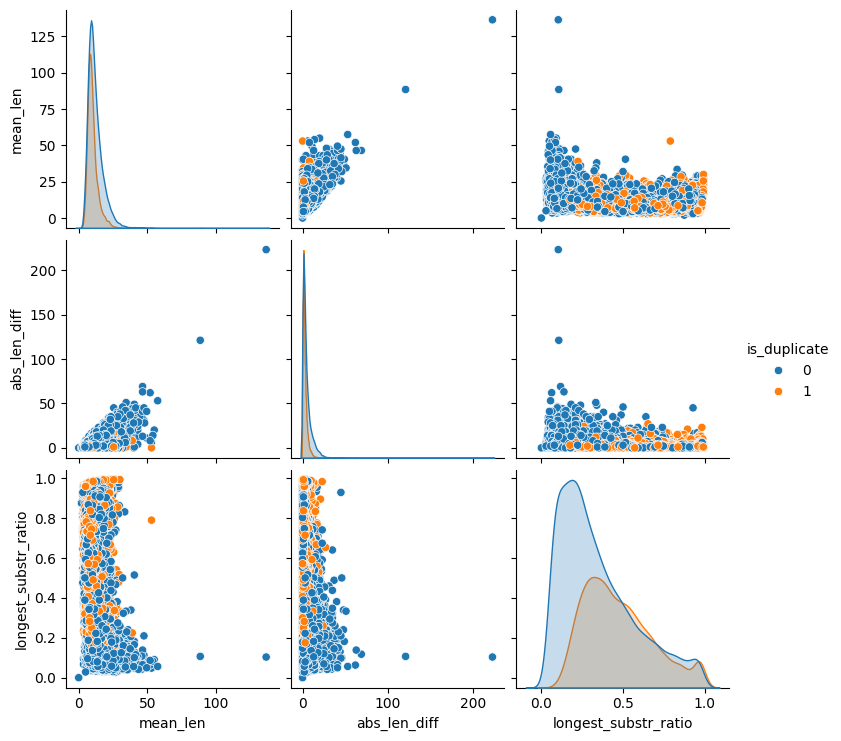

In [102]:
sns.pairplot(df[['mean_len', 'abs_len_diff','longest_substr_ratio', 'is_duplicate']],hue='is_duplicate')

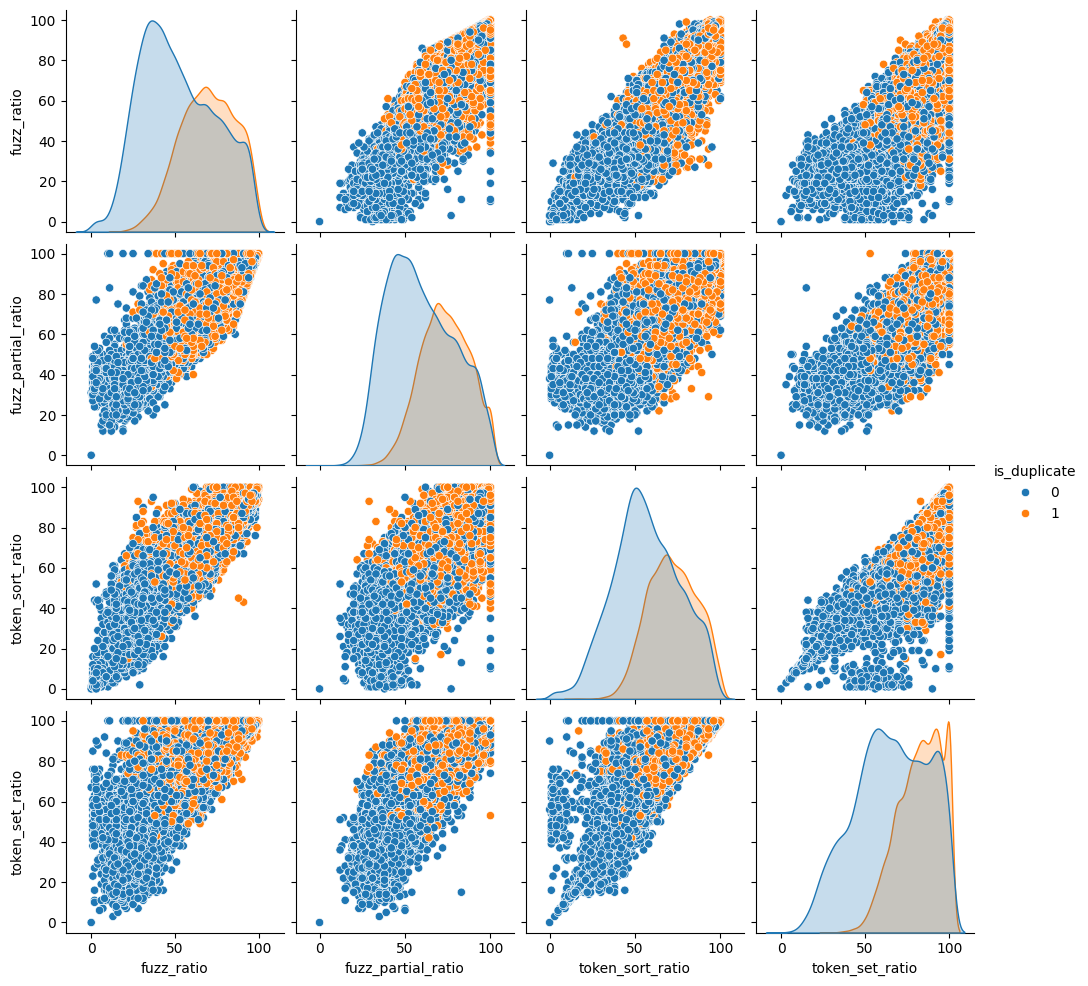

In [103]:
sns.pairplot(df[['fuzz_ratio', 'fuzz_partial_ratio','token_sort_ratio','token_set_ratio', 'is_duplicate']],hue='is_duplicate')

In [104]:
df.head()


,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
0,the united nations organization has made the w...,how do i not fall asleep and distracted after ...,0,102,76,17,15,1,30,0.03,...,0.066666,0.0,0.0,0.0,15.0,0.064935,25,24,30,30
1,what is the difference between the army and th...,why and how do the marines fall under differin...,0,78,67,13,13,4,23,0.17,...,0.307690,0.0,0.0,1.0,12.5,0.191176,40,50,65,50
2,why india is not releasing video of surgical s...,why cant india expose pakistan s support to te...,1,63,93,11,15,7,26,0.27,...,0.466664,0.0,1.0,4.0,13.0,0.546875,65,70,68,84
3,why is rotatum is an unphysical quantity,what is the difference between rotatum power ...,0,40,61,7,11,2,16,0.12,...,0.222220,0.0,0.0,2.0,8.0,0.219512,38,39,38,43
4,what is the best way to learn discipline,how do i develop discipline,1,40,27,8,5,1,13,0.08,...,0.124998,1.0,0.0,3.0,6.5,0.392857,54,64,51,54


In [105]:
x = df.drop(columns = "is_duplicate",axis = 1)
y = df['is_duplicate']

In [106]:
x_train,x_val,y_train,y_val = train_test_split(x,y,test_size = 0.3,random_state = 42)

In [107]:
x_train.head()

,question1,question2,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share,cwc_min,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
28465,what does it mean to have customer service skills,how do i improve my customer service skills,49,43,9,8,3,17,0.18,0.749981,...,0.333330,1.0,0.0,1.0,8.5,0.545455,70,74,70,70
27622,i love the idea of free code camp however i ...,what should be the necessary documentation req...,71,144,19,27,5,40,0.12,0.000000,...,0.159999,0.0,0.0,9.0,20.5,0.166667,14,34,42,42
28376,if a bollywood movie were made on the life and...,if a bollywood movie were made on the life and...,106,114,21,22,20,43,0.47,0.899991,...,0.904758,1.0,1.0,1.0,20.5,0.869159,94,92,89,96
10917,how do i use ms word,what are the best ways to use ms word,20,37,6,9,3,15,0.20,0.999967,...,0.333330,1.0,0.0,3.0,7.5,0.571429,49,76,46,71
27234,what is bulk density of cement aggregate sand,how many sand cement stone and water in 1m3,47,45,10,11,3,19,0.16,0.399992,...,0.222220,0.0,0.0,1.0,8.5,0.195652,43,48,48,41


In [108]:
tfidf = TfidfVectorizer(max_features = 3000)

In [109]:
qid = list(x_train['question1']) + list(x_train['question2'])
qid = pd.Series(qid)

In [110]:
tfidf.fit_transform(qid)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 371422 stored elements and shape (42000, 3000)>

In [111]:
arr1, arr2 = np.vsplit(tfidf.fit_transform(qid).toarray(),2)

In [112]:
temp_df1 = pd.DataFrame(arr1,index = x_train.index)
temp_df2 = pd.DataFrame(arr2,index = x_train.index)
temp_df = pd.concat((temp_df1,temp_df2),axis = 1)

In [113]:
temp_df.columns = [i for i in range(1, 6001)]

In [114]:
x_train_tf = pd.concat((temp_df,x_train),axis = 1)
x_train_tf

,1,2,3,4,5,6,7,8,9,10,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
28465,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.333330,1.0,0.0,1.0,8.5,0.545455,70,74,70,70
27622,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.159999,0.0,0.0,9.0,20.5,0.166667,14,34,42,42
28376,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.904758,1.0,1.0,1.0,20.5,0.869159,94,92,89,96
10917,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.333330,1.0,0.0,3.0,7.5,0.571429,49,76,46,71
27234,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.222220,0.0,0.0,1.0,8.5,0.195652,43,48,48,41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29802,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.599996,0.0,1.0,4.0,13.0,0.476190,74,84,74,89
5390,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.181817,1.0,0.0,3.0,9.5,0.368421,56,47,49,62
860,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.636358,1.0,1.0,4.0,9.0,0.529412,79,70,79,100
15795,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.058823,0.0,0.0,5.0,14.5,0.060606,28,29,34,37


In [115]:
x_train_tf.drop(columns = ['question1','question2'],axis = 1, inplace = True)
x_train_tf.columns = x_train_tf.columns.astype('str')

In [116]:
qid = list(x_val['question1']) + list(x_val['question2'])
qid = pd.Series(qid)
tfidf.transform(qid)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 156736 stored elements and shape (18000, 3000)>

In [117]:
arr3, arr4 = np.vsplit(tfidf.transform(qid).toarray(),2)
temp_df3 = pd.DataFrame(arr3,index = x_val.index)
temp_df4 = pd.DataFrame(arr4,index = x_val.index)
temp_df_v = pd.concat((temp_df3,temp_df4),axis = 1)
temp_df_v.columns = [i for i in range(1, 6001)]

x_val_tf = pd.concat((temp_df_v,x_val),axis = 1)
x_val_tf.drop(columns = ['question1','question2'],axis = 1, inplace = True)
x_val_tf.columns = x_val_tf.columns.astype('str')

In [118]:
model = LogisticRegression(class_weight= 'balanced')
model.fit(x_train_tf,y_train)
y_pred = model.predict(x_val_tf)
print(classification_report(y_val,y_pred))
print(accuracy_score(y_val,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.64      0.72      5737
           1       0.55      0.76      0.63      3263

    accuracy                           0.68      9000
   macro avg       0.68      0.70      0.68      9000
weighted avg       0.72      0.68      0.69      9000

0.6842222222222222


In [119]:
model = RandomForestClassifier()
model.fit(x_train_tf,y_train)
y_pred = model.predict(x_val_tf)
y_pred1 = model.predict(x_train_tf)
print(classification_report(y_val,y_pred))
print(accuracy_score(y_val,y_pred))
print(log_loss(y_val,y_pred))
print(log_loss(y_train,y_pred1))

              precision    recall  f1-score   support

           0       0.82      0.85      0.83      5737
           1       0.71      0.66      0.69      3263

    accuracy                           0.78      9000
   macro avg       0.76      0.76      0.76      9000
weighted avg       0.78      0.78      0.78      9000

0.7814444444444445
7.877540690710382
0.0017163644471010384


In [120]:
model1 = XGBClassifier()

model1.fit(x_train_tf, y_train)

# Class predictions
y_pred = model1.predict(x_val_tf)
y_pred1 = model1.predict(x_train_tf)

# Probability predictions
y_pred_prob = model1.predict_proba(x_val_tf)
y_pred_prob1 = model1.predict_proba(x_train_tf)

print(classification_report(y_val, y_pred))

print("Validation Accuracy:", accuracy_score(y_val, y_pred))

print("Validation Log Loss:", log_loss(y_val, y_pred_prob))

print("Training Log Loss:", log_loss(y_train, y_pred_prob1))

              precision    recall  f1-score   support

           0       0.83      0.83      0.83      5737
           1       0.70      0.69      0.70      3263

    accuracy                           0.78      9000
   macro avg       0.77      0.76      0.76      9000
weighted avg       0.78      0.78      0.78      9000

Validation Accuracy: 0.7827777777777778
Validation Log Loss: 0.4245578526056858
Training Log Loss: 0.32213468571756937


In [121]:
import pickle

# Save model
with open('tfidf.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

In [122]:
with open('xgb.pkl','wb') as f:
    pickle.dump(model1,f)